# 🌿 AgroIntelli — Notebook 01: Data Ingestion, Dataset Fusion & Multimodal Preprocessing
### Complete 39-Class Dataset Pipeline (PlantVillage + PlantDoc)

## 📥 Direct Dataset Download Links
If the raw zip archives are not present on your device, download them from these official repositories:
* 📦 **PlantVillage Dataset**: [PlantVillage GitHub Master Zip](https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip)
* 📦 **PlantDoc Dataset**: [PlantDoc GitHub Master Zip](https://github.com/pratikkayal/PlantDoc-Dataset/archive/refs/heads/master.zip)

Place downloaded `.zip` files into `notebooks/agrointelli_data/data/raw/` or let the automated downloader cell below fetch them automatically.

In [1]:
import os
import sys
import json
import zipfile
import random
import urllib.request
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Set seeds for scientific reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ OpenCV Version: {cv2.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ Acceleration Mode: {'GPU Available: ' + str(gpus) if gpus else 'CPU Mode'}")

✅ TensorFlow Version: 2.19.1
✅ OpenCV Version: 4.13.0
✅ Acceleration Mode: CPU Mode


## 🌐 1. Automated Dataset Download & Archive Extraction

In [2]:
BASE_DATA_DIR = Path("./agrointelli_data/data")
RAW_DIR = BASE_DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Dataset Source Mirrors
PLANTVILLAGE_URL = "https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip"
PLANTDOC_URL = "https://github.com/pratikkayal/PlantDoc-Dataset/archive/refs/heads/master.zip"

def download_progress_hook(count, block_size, total_size):
    percent = int(count * block_size * 100 / total_size) if total_size > 0 else 0
    sys.stdout.write(f"\r   Downloading... {percent}%")
    sys.stdout.flush()

def download_and_extract():
    pv_zip = RAW_DIR / "plantvillage.zip"
    pd_zip = RAW_DIR / "plantdoc.zip"
    pv_dir = RAW_DIR / "plantvillage"
    pd_dir = RAW_DIR / "plantdoc"
    
    # 1. Download & Extract PlantVillage if missing
    if not (pv_zip.exists() or pv_dir.exists()):
        print(f"🌐 Downloading PlantVillage Dataset from {PLANTVILLAGE_URL}...")
        try:
            urllib.request.urlretrieve(PLANTVILLAGE_URL, pv_zip, reporthook=download_progress_hook)
            print("\n✅ PlantVillage Download Complete!")
        except Exception as e:
            print(f"\n⚠️ Could not download PlantVillage automatically: {e}")
            print(f"   Please manually download from {PLANTVILLAGE_URL} and save as {pv_zip.resolve()}")
            
    if pv_zip.exists() and not pv_dir.exists():
        print(f"📦 Extracting {pv_zip.name}...")
        with zipfile.ZipFile(pv_zip, 'r') as z:
            z.extractall(pv_dir)
        print("✅ PlantVillage extracted successfully.")

    # 2. Download & Extract PlantDoc if missing
    if not (pd_zip.exists() or pd_dir.exists()):
        print(f"🌐 Downloading PlantDoc Dataset from {PLANTDOC_URL}...")
        try:
            urllib.request.urlretrieve(PLANTDOC_URL, pd_zip, reporthook=download_progress_hook)
            print("\n✅ PlantDoc Download Complete!")
        except Exception as e:
            print(f"\n⚠️ Could not download PlantDoc automatically: {e}")
            print(f"   Please manually download from {PLANTDOC_URL} and save as {pd_zip.resolve()}")
            
    if pd_zip.exists() and not pd_dir.exists():
        print(f"📦 Extracting {pd_zip.name}...")
        with zipfile.ZipFile(pd_zip, 'r') as z:
            z.extractall(pd_dir)
        print("✅ PlantDoc extracted successfully.")

download_and_extract()
print(f"📂 Raw Data Directory: {RAW_DIR.resolve()}")

📂 Raw Data Directory: C:\Users\rahul\Desktop\pd\AgroIntelli_Project\notebooks\agrointelli_data\data\raw


## 📁 2. Full 39 Unified Target Taxonomy Mapping

In [3]:
FULL_TAXONOMY = {
    "apple_apple_scab": ["apple___apple_scab", "apple scab leaf"],
    "apple_black_rot": ["apple___black_rot"],
    "apple_cedar_apple_rust": ["apple___cedar_apple_rust", "apple rust leaf"],
    "apple_healthy": ["apple___healthy", "apple leaf"],
    "background_without_leaves": ["background_without_leaves"],
    "blueberry_healthy": ["blueberry___healthy", "blueberry leaf"],
    "cherry_powdery_mildew": ["cherry___powdery_mildew"],
    "cherry_healthy": ["cherry___healthy", "cherry leaf"],
    "corn_gray_leaf_spot": ["corn___cercospora_leaf_spot gray_leaf_spot", "corn gray leaf spot"],
    "corn_common_rust": ["corn___common_rust", "corn rust leaf"],
    "corn_northern_leaf_blight": ["corn___northern_leaf_blight", "corn leaf blight"],
    "corn_healthy": ["corn___healthy"],
    "grape_black_rot": ["grape___black_rot", "grape leaf black rot"],
    "grape_esca_black_measles": ["grape___esca_(black_measles)"],
    "grape_leaf_blight": ["grape___leaf_blight_(isariopsis_leaf_spot)"],
    "grape_healthy": ["grape___healthy", "grape leaf"],
    "orange_haunglongbing_citrus_greening": ["orange___haunglongbing_(citrus_greening)"],
    "peach_bacterial_spot": ["peach___bacterial_spot"],
    "peach_healthy": ["peach___healthy", "peach leaf"],
    "pepper_bacterial_spot": ["pepper,_bell___bacterial_spot", "bell_pepper leaf spot"],
    "pepper_healthy": ["pepper,_bell___healthy", "bell_pepper leaf"],
    "potato_early_blight": ["potato___early_blight", "potato leaf early blight"],
    "potato_late_blight": ["potato___late_blight", "potato leaf late blight"],
    "potato_healthy": ["potato___healthy"],
    "raspberry_healthy": ["raspberry___healthy", "raspberry leaf"],
    "soybean_healthy": ["soybean___healthy", "soyabean leaf"],
    "squash_powdery_mildew": ["squash___powdery_mildew", "squash powdery mildew leaf"],
    "strawberry_leaf_scorch": ["strawberry___leaf_scorch"],
    "strawberry_healthy": ["strawberry___healthy", "strawberry leaf"],
    "tomato_bacterial_spot": ["tomato___bacterial_spot", "tomato leaf bacterial spot"],
    "tomato_early_blight": ["tomato___early_blight", "tomato early blight leaf"],
    "tomato_late_blight": ["tomato___late_blight", "tomato leaf late blight"],
    "tomato_leaf_mold": ["tomato___leaf_mold", "tomato mold leaf"],
    "tomato_septoria_leaf_spot": ["tomato___septoria_leaf_spot", "tomato septoria leaf spot"],
    "tomato_spider_mites_two_spotted_spider_mite": ["tomato___spider_mites two-spotted_spider_mite", "tomato two spotted spider mites leaf"],
    "tomato_target_spot": ["tomato___target_spot"],
    "tomato_yellow_leaf_curl_virus": ["tomato___tomato_yellow_leaf_curl_virus", "tomato leaf yellow virus"],
    "tomato_mosaic_virus": ["tomato___tomato_mosaic_virus", "tomato leaf mosaic virus"],
    "tomato_healthy": ["tomato___healthy", "tomato leaf"]
}

ALL_CLASSES = sorted(list(FULL_TAXONOMY.keys()))
CLASS_TO_IDX = {cls: i for i, cls in enumerate(ALL_CLASSES)}
IDX_TO_CLASS = {i: cls for i, cls in enumerate(ALL_CLASSES)}

print(f"📋 Defined {len(ALL_CLASSES)} Unified Crop Disease Classes:")
for k, v in list(CLASS_TO_IDX.items())[:10]:
    print(f"   [{v:02d}] {k}")
print(f"   ... and {len(ALL_CLASSES)-10} more classes.")

📋 Defined 39 Unified Crop Disease Classes:
   [00] apple_apple_scab
   [01] apple_black_rot
   [02] apple_cedar_apple_rust
   [03] apple_healthy
   [04] background_without_leaves
   [05] blueberry_healthy
   [06] cherry_healthy
   [07] cherry_powdery_mildew
   [08] corn_common_rust
   [09] corn_gray_leaf_spot
   ... and 29 more classes.


## 📊 3. Full Dataset Discovery & Ingestion

In [4]:
def map_folder_to_class(folder_name):
    fn_lower = folder_name.lower().strip()
    for canonical_cls, aliases in FULL_TAXONOMY.items():
        if fn_lower == canonical_cls:
            return canonical_cls
        for alias in aliases:
            if alias in fn_lower or fn_lower in alias:
                return canonical_cls
    return None

def discover_fused_dataset(raw_dir):
    records = []
    for root, _, files in os.walk(raw_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = Path(root) / file
                folder_name = full_path.parent.name
                canonical_cls = map_folder_to_class(folder_name)
                if canonical_cls:
                    source = "PlantDoc" if "plantdoc" in str(full_path).lower() else "PlantVillage"
                    records.append({
                        "file_path": str(full_path),
                        "class_name": canonical_cls,
                        "class_idx": CLASS_TO_IDX[canonical_cls],
                        "source": source
                    })
    return pd.DataFrame(records)

df_dataset = discover_fused_dataset(RAW_DIR)
print(f"✅ Total Discovered Fused Images: {len(df_dataset)}")
if len(df_dataset) > 0:
    print("\n📊 Samples by Source:")
    print(df_dataset['source'].value_counts())
    print(f"\n📊 Total Unified Classes Represented: {df_dataset['class_name'].nunique()} / {len(ALL_CLASSES)}")
display(df_dataset.head())

✅ Total Discovered Fused Images: 64058

📊 Samples by Source:
source
PlantVillage    61486
PlantDoc         2572
Name: count, dtype: int64

📊 Total Unified Classes Represented: 39 / 39


,file_path,class_name,class_idx,source
0,agrointelli_data\data\raw\plantdoc\PlantDoc-Da...,apple_healthy,3,PlantDoc
1,agrointelli_data\data\raw\plantdoc\PlantDoc-Da...,apple_healthy,3,PlantDoc
2,agrointelli_data\data\raw\plantdoc\PlantDoc-Da...,apple_healthy,3,PlantDoc
3,agrointelli_data\data\raw\plantdoc\PlantDoc-Da...,apple_healthy,3,PlantDoc
4,agrointelli_data\data\raw\plantdoc\PlantDoc-Da...,apple_healthy,3,PlantDoc


## 📈 4. Class Distribution EDA

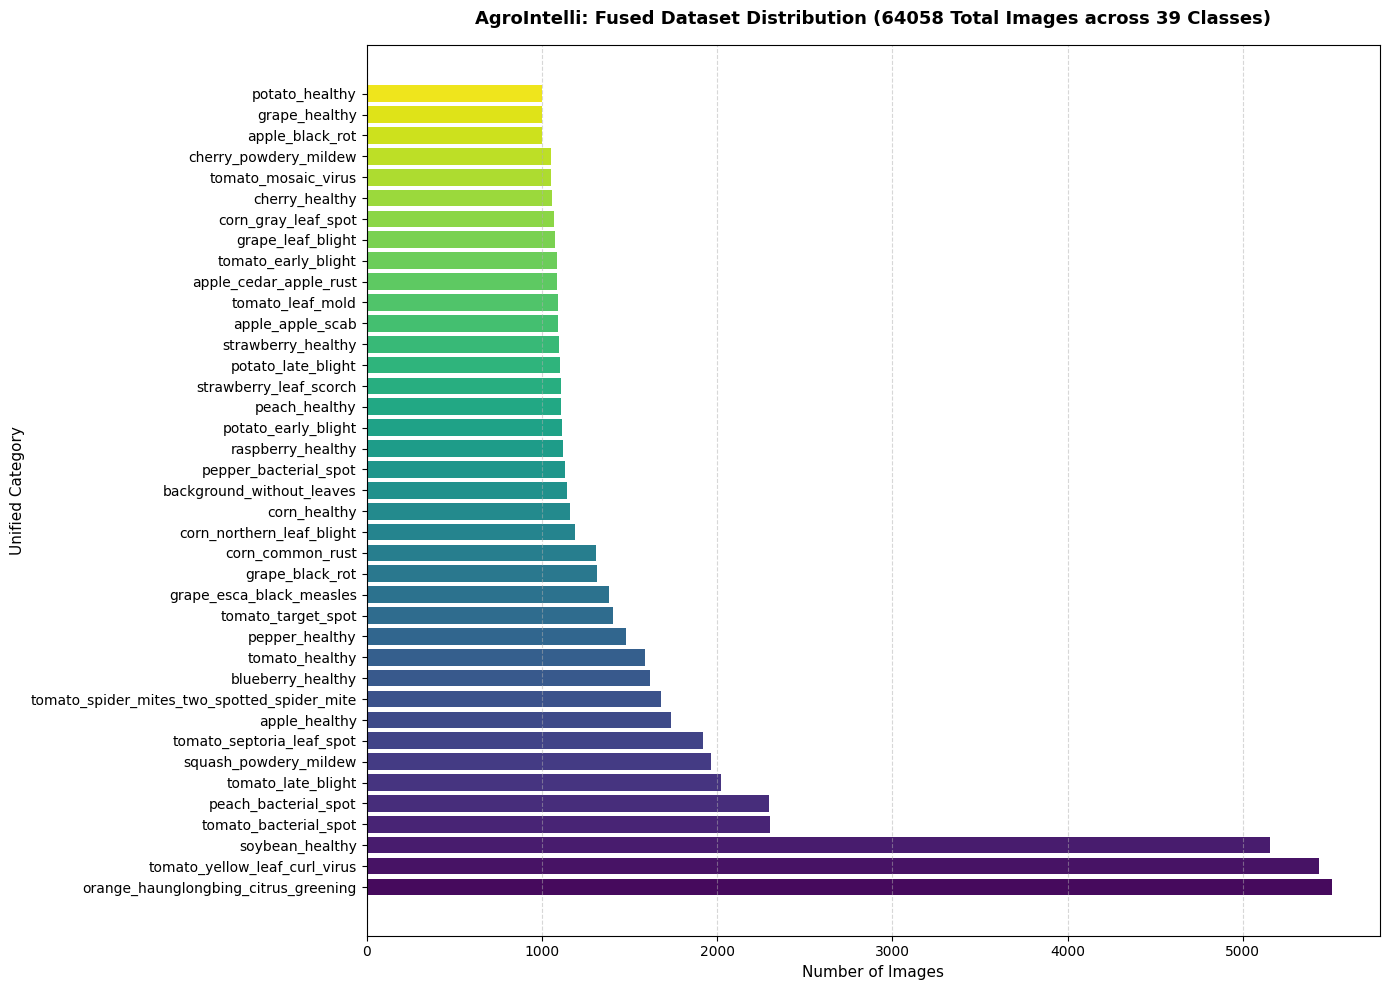

In [5]:
if len(df_dataset) > 0:
    plt.figure(figsize=(14, 10))
    class_counts = df_dataset['class_name'].value_counts()
    colors = sns.color_palette("viridis", len(class_counts))
    bars = plt.barh(class_counts.index, class_counts.values, color=colors)
    plt.title(f"AgroIntelli: Fused Dataset Distribution ({len(df_dataset)} Total Images across {len(class_counts)} Classes)", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Number of Images", fontsize=11)
    plt.ylabel("Unified Category", fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## 🌦️ 5. Multimodal Weather Feature Synthesis

In [6]:
def synthesize_weather_vector(class_name):
    cn = str(class_name).lower()
    if "late_blight" in cn or "mold" in cn:
        temp = np.random.normal(19.0, 3.0)
        humidity = np.random.normal(88.0, 5.0)
        rain = np.random.exponential(3.5)
        wind = np.random.normal(12.0, 4.0)
    elif "early_blight" in cn or "spot" in cn or "scab" in cn:
        temp = np.random.normal(26.0, 3.5)
        humidity = np.random.normal(78.0, 6.0)
        rain = np.random.exponential(1.5)
        wind = np.random.normal(14.0, 5.0)
    elif "rust" in cn or "powdery" in cn:
        temp = np.random.normal(22.0, 4.0)
        humidity = np.random.normal(72.0, 7.0)
        rain = np.random.exponential(1.0)
        wind = np.random.normal(24.0, 6.0)
    elif "healthy" in cn or "background" in cn:
        temp = np.random.normal(24.0, 4.0)
        humidity = np.random.normal(55.0, 8.0)
        rain = 0.0
        wind = np.random.normal(10.0, 3.0)
    else:
        temp = np.random.normal(28.0, 4.0)
        humidity = np.random.normal(82.0, 6.0)
        rain = np.random.exponential(2.0)
        wind = np.random.normal(15.0, 4.0)

    norm_temp = float(np.clip((temp + 10.0) / 60.0, 0.0, 1.0))
    norm_humidity = float(np.clip(humidity / 100.0, 0.0, 1.0))
    norm_rain = float(np.clip(rain / 50.0, 0.0, 1.0))
    norm_wind = float(np.clip(wind / 80.0, 0.0, 1.0))
    return np.array([norm_temp, norm_humidity, norm_rain, norm_wind], dtype=np.float32)

sample_w = synthesize_weather_vector("tomato_late_blight")
print(f"✅ Sample Weather Vector for Tomato Late Blight: {sample_w}")

✅ Sample Weather Vector for Tomato Late Blight: [0.50816905 0.8730868  0.0921722  0.09440599]


## ✂️ 6. Stratified Dataset Splitting

In [7]:
if len(df_dataset) > 0:
    train_df, test_df = train_test_split(df_dataset, test_size=0.20, stratify=df_dataset['class_name'], random_state=SEED)
    val_df, test_df = train_test_split(test_df, test_size=0.50, stratify=test_df['class_name'], random_state=SEED)
    print(f"📊 Train Set:      {len(train_df)} samples ({len(train_df)/len(df_dataset)*100:.1f}%)")
    print(f"📊 Validation Set: {len(val_df)} samples ({len(val_df)/len(df_dataset)*100:.1f}%)")
    print(f"📊 Test Set:       {len(test_df)} samples ({len(test_df)/len(df_dataset)*100:.1f}%)")

📊 Train Set:      51246 samples (80.0%)
📊 Validation Set: 6406 samples (10.0%)
📊 Test Set:       6406 samples (10.0%)


## 💾 7. Export Canonical Class Index Map to Backend

In [8]:
EXPORT_DIR = Path("../backend/models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

class_map_file = EXPORT_DIR / "class_index_map.json"
with open(class_map_file, "w", encoding="utf-8") as f:
    json.dump(CLASS_TO_IDX, f, indent=2)

print(f"✅ Canonical Class Index Map exported to: {class_map_file.resolve()}")
print("🚀 Notebook 01 complete! All 39 classes preprocessed. Proceed to Notebook 02 (MobileNetV3) or Notebook 03 (EfficientNet-B0).")

✅ Canonical Class Index Map exported to: C:\Users\rahul\Desktop\pd\AgroIntelli_Project\backend\models\class_index_map.json
🚀 Notebook 01 complete! All 39 classes preprocessed. Proceed to Notebook 02 (MobileNetV3) or Notebook 03 (EfficientNet-B0).
